<div align="center">
  <b><br>
  <b><br>
  <b><font color="white" size="8">PROCESAMIENTO DE DATOS DEL GOES-19 CON PYTHON</font><br>
  <b><br>
  <b><font color="white" size="5">Joao Huamán</font><br>
  <b><br>
  <b><font color="white" size="4">31 de marzo y 01 de abril de 2026</font><br>
  <b><br>
</div>

# Grafiquemos la imagenes de satélite con una paleta de colores personalizada

Primero, instalemos las librerías que vamos a necesitar:

In [1]:
!pip install cartopy
!pip install netCDF4
!pip install GOES
!pip install custom-color-palette
!pip install pyproj
!pip install pyresample

Ahora, montemos nuestro Google drive en el entorno del Colab:

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Creemos la carpeta de trabajo (por si aún no ha sido creada):

In [3]:
import os
os.makedirs('/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/',exist_ok=True)

Descarguemos imagenes de los canales 2, 8 y 13 del ABI:

In [4]:
import GOES

flist = GOES.download('goes19',
                      'ABI-L2-CMIPF',
                      DateTimeIni='20250607-203000',
                      DateTimeFin='20250607-203100',
                      channel=['02','08','13'],
                      path_out='/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/')

Files:
  OR_ABI-L2-CMIPF-M6C02_G19_s20251582030209_e20251582039518_c20251582039570.nc already exists.
  OR_ABI-L2-CMIPF-M6C08_G19_s20251582030209_e20251582039518_c20251582039581.nc already exists.
  OR_ABI-L2-CMIPF-M6C13_G19_s20251582030209_e20251582039529_c20251582039581.nc already exists.


In [5]:
print(*flist, sep='\n')

/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/OR_ABI-L2-CMIPF-M6C02_G19_s20251582030209_e20251582039518_c20251582039570.nc
/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/OR_ABI-L2-CMIPF-M6C08_G19_s20251582030209_e20251582039518_c20251582039581.nc
/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/OR_ABI-L2-CMIPF-M6C13_G19_s20251582030209_e20251582039529_c20251582039581.nc


Guardemos el nombre de cada archivo en una variable:

In [6]:
file_c02 = flist[0]
file_c08 = flist[1]
file_c13 = flist[2]

Para crear una paleta de colores personalizada, vamos a usar la libreria [**custom_color_palette**](https://github.com/joaohenry23/custom_color_palette).

Esta libreria utiliza los [colores](https://matplotlib.org/stable/gallery/color/named_colors.html) y [paletas](https://matplotlib.org/stable/users/explain/colors/colormaps.html) predefinidas por matplotlib. Ademas, podemos usar hexacodes o RGB para definir los colores (ver https://htmlcolorcodes.com/es/).

# Grafiquemos el canal 13 con una paleta personalizada

Definamos la paleta de colores para el canal 13

In [7]:
# Creación de una paleta de colores personalizada
import custom_color_palette as ccp
import matplotlib.pyplot as plt

# Definimos los colores y el intervalo que ocupa en la paleta
paleta_1 = [['maroon','red','darkorange','#ffff00','forestgreen','cyan','royalblue',(148/255,0/255,211/255)], # sequencia de colores o paleta de matplotlib
            ccp.range(-90.0,-30.0,1.0) # intervalo que abarcan los colores
            ]

paleta_2 = [plt.cm.Greys, # sequencia de colores o paleta de matplotlib
            ccp.range(-30.0,60.0,1.0), # intervalo que abarcan los colores
            [ccp.range(-90.0,60.0,1.0),-30.0,60.0] # parametro opcional que estira y recorta la paleta de colores
            ]

# Creamos la paleta personalizada
cmap, ticks, norm, bounds = ccp.creates_palette([paleta_1,  paleta_2], extend='both')
cbticks = ccp.range(-90,60,15)

In [8]:
# Obteniendo el dato (imagen de satélite)

import GOES

ds = GOES.open_dataset(file_c13) # Leemos el archivo nc

# Obtenemos el dato (imagen de satélite) y sus coordenadas (de las esquinas de cada elemento)
domain = [-90.0,-60.0,-21.0,2.0] # Definimos el dominio de longitud y latitud
CMI, LonCor, LatCor = ds.image('CMI', lonlat='corner', domain=domain)

# Atributos del dato (imagen de satélite)
sat = ds.attribute('platform_ID')
time = ds.attribute('time_coverage_start')
band_id = ds.variable('band_id').data[0]
wl = ds.variable('band_wavelength').data[0]
long_name = CMI.long_name # Lo obtenemos de CMI
units = CMI.units # Lo obtenemos de CMI
long_name = 'Temperatura de brillo'
units = '°C'

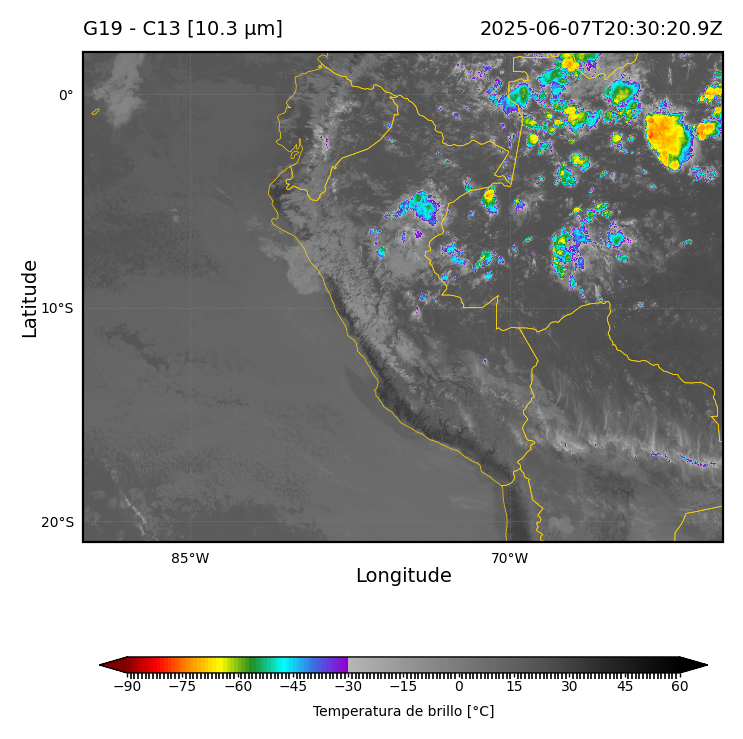

In [9]:
# Graficando el dato (imagen de satélite)

import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt

proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

#domain = [-120.0,-40.0,-50.0,50.0]

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='50m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='gold', linewidth=0.25) # Adicionamos los limites

img = ax.pcolormesh(LonCor.data, LatCor.data, CMI.data-273.15, transform=proj_sat, cmap=cmap, norm=norm)

# Configuración de la barra de colores
cb = plt.colorbar(img, ticks=cbticks, orientation='horizontal', extend='both', cax=fig.add_axes([0.12, 0.065, 0.76, 0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)
cb.set_label(label='{} [{}]'.format(long_name, units), size=5, color='black', weight='normal')
cb.outline.set_linewidth(0.5)

# Configuración del titulo
ax.set_title('{} - C{} [{:.1f} μm]'.format(sat, band_id, wl), fontsize=7, loc='left')
ax.set_title(time, fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_C13.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


¡Eliminemos las variables para evitar que se llene la memoria RAM del Colab!

In [10]:
del CMI, LonCor, LatCor, ds, img, fig

# Grafiquemos el canal 08 con una paleta personalizada

Definamos la paleta de colores para el canal 08

In [11]:
# Creación de una paleta de colores personalizada

import custom_color_palette as ccp
import matplotlib.pyplot as plt

# Definimos los colores y el intervalo que ocupa en la paleta
paleta_1 = [['#550054',(174/255,46/255,172/255),(239/255,139/255,238/255)],
            ccp.range(-90.0,-75.0,0.5)
            ]
paleta_2 = [[(0/255,54/255,0/255), 'lawngreen'],
            ccp.range(-75.0,-60.0,0.5)
            ]
paleta_3 = [['darkblue', 'white'],
            ccp.range(-60.0,-45.0,0.5)
            ]
paleta_4 = [[(240/255,240/255,240/255), (60/255,60/255,60/255)],
            ccp.range(-45.0,-25.0,0.5),
            [ccp.range(-46.0,-25.0,0.5),-45.0,-25.0]
            ]
paleta_5 = [[(65/255,36/255,2/255), 'orange', 'red', 'darkred', (63/255,0/255,0/255), 'black'],
            ccp.range(-25.0,15.0,0.5)
            ]

# Creamos la paleta personalizada
cmap, ticks, norm, bounds = ccp.creates_palette([paleta_1, paleta_2, paleta_3, paleta_4, paleta_5], extend='both')
cbticks = ccp.range(-90,15,15)

In [12]:
# Obteniendo el dato (imagen de satélite)

import GOES

ds = GOES.open_dataset(file_c08) # Leemos el archivo nc

# Obtenemos el dato (imagen de satélite) y sus coordenadas (de las esquinas de cada elemento)
domain = [-90.0,-60.0,-21.0,2.0] # Definimos el dominio de longitud y latitud
CMI, LonCor, LatCor = ds.image('CMI', lonlat='corner', domain=domain)

# Atributos del dato (imagen de satélite)
sat = ds.attribute('platform_ID')
time = ds.attribute('time_coverage_start')
band_id = ds.variable('band_id').data[0]
wl = ds.variable('band_wavelength').data[0]
long_name = CMI.long_name # Lo obtenemos de CMI
units = CMI.units # Lo obtenemos de CMI
long_name = 'Temperatura de brillo'
units = '°C'

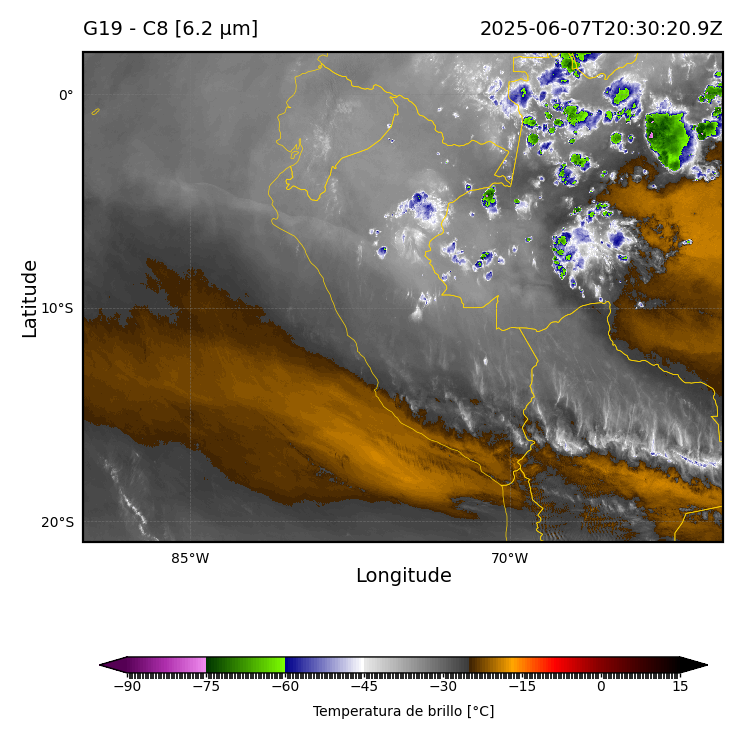

In [13]:
# Graficando el dato (imagen de satélite)

import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt

proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='50m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='gold', linewidth=0.25) # Adicionamos los limites

img = ax.pcolormesh(LonCor.data, LatCor.data, CMI.data-273.15, transform=proj_sat, cmap=cmap, norm=norm)

# Configuración de la barra de colores
cb = plt.colorbar(img, ticks=cbticks, orientation='horizontal', extend='both', cax=fig.add_axes([0.12, 0.065, 0.76, 0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)
cb.set_label(label='{} [{}]'.format(long_name, units), size=5, color='black', weight='normal')
cb.outline.set_linewidth(0.5)

# Configuración del titulo
ax.set_title('{} - C{} [{:.1f} μm]'.format(sat, band_id, wl), fontsize=7, loc='left')
ax.set_title(time, fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_C08.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


¡Eliminemos las variables para evitar que se llene la memoria RAM del Colab!

In [14]:
del CMI, LonCor, LatCor, ds, img, fig

# Grafiquemos el canal 02 con una paleta personalizada

Definamos la paleta de colores para el canal 02

In [15]:
# Creación de una paleta de colores personalizada

import custom_color_palette as ccp
import matplotlib.pyplot as plt

# Definimos los colores y el intervalo que ocupa en la paleta
paleta = [ plt.cm.Greys_r,  ccp.range(0.0,1.0,0.01) ]

# Creamos la paleta personalizada
cmap, ticks, norm, bounds = ccp.creates_palette([paleta], extend='both')
cbticks = ccp.range(0.0,1.0,0.1)

In [16]:
# Obteniendo el dato (imagen de satélite)

import GOES

ds = GOES.open_dataset(file_c02) # Leemos el archivo nc

# Obtenemos el dato (imagen de satélite) y sus coordenadas (de las esquinas de cada elemento)
domain = [-90.0,-60.0,-21.0,2.0] # Definimos el dominio de longitud y latitud
CMI, LonCen, LatCen = ds.image('CMI', lonlat='center', domain=domain)

# Atributos del dato (imagen de satélite)
sat = ds.attribute('platform_ID')
time = ds.attribute('time_coverage_start')
band_id = ds.variable('band_id').data[0]
wl = ds.variable('band_wavelength').data[0]
long_name = CMI.long_name # Lo obtenemos de CMI
units = CMI.units # Lo obtenemos de CMI

# Calculamos las esquinas a partir del centro de los píxeles
LonCor, LatCor = GOES.calculate_corners(LonCen, LatCen)

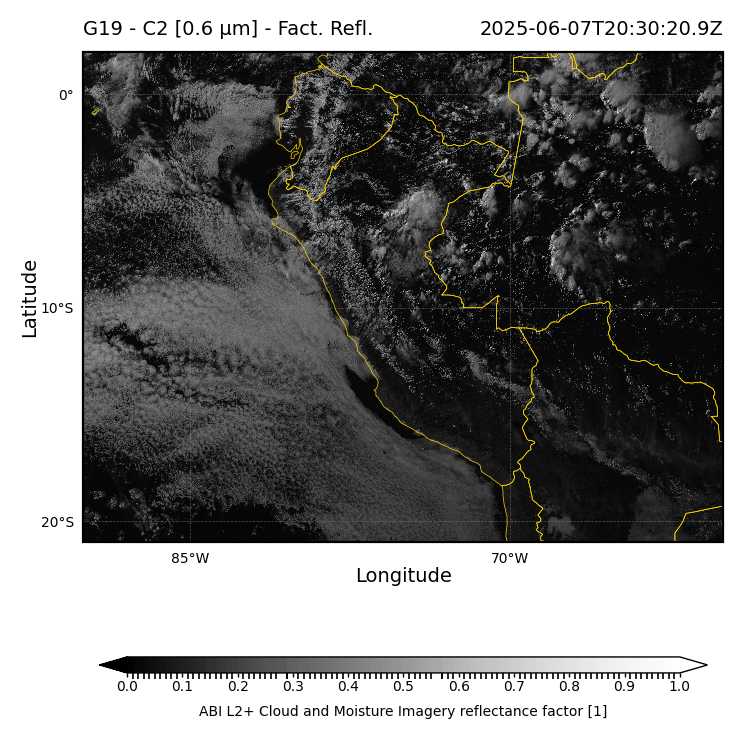

In [17]:
# Graficando el dato (imagen de satélite)

import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt

proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='50m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='gold', linewidth=0.25) # Adicionamos los limites

img = ax.pcolormesh(LonCor.data, LatCor.data, CMI.data, transform=proj_sat, cmap=cmap, norm=norm)

# Configuración de la barra de colores
cb = plt.colorbar(img, ticks=cbticks, orientation='horizontal', extend='both', cax=fig.add_axes([0.12, 0.065, 0.76, 0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)
cb.set_label(label='{} [{}]'.format(long_name, units), size=5, color='black', weight='normal')
cb.outline.set_linewidth(0.5)

# Configuración del titulo
ax.set_title('{} - C{} [{:.1f} μm] - Fact. Refl.'.format(sat, band_id, wl), fontsize=7, loc='left')
ax.set_title(time, fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_C01.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


Lo que hemos graficado es el **factor de reflectacia**, pero lo que queremos graficar es la **reflectancia**, para calcularla debemos realizar la siguiente conversión:

In [18]:
CMI_refl = CMI.refl_fact_to_refl(LonCen, LatCen)

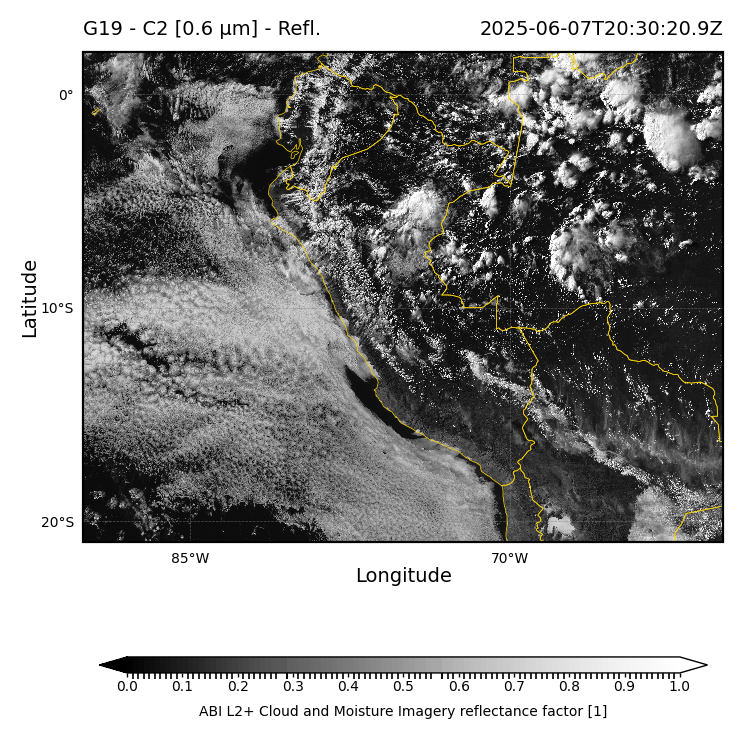

In [19]:
# Graficando el dato (imagen de satélite)

import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt

proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='50m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='gold', linewidth=0.25) # Adicionamos los limites

img = ax.pcolormesh(LonCor.data, LatCor.data, CMI_refl.data, transform=proj_sat, cmap=cmap, norm=norm)

# Configuración de la barra de colores
cb = plt.colorbar(img, ticks=cbticks, orientation='horizontal', extend='both', cax=fig.add_axes([0.12, 0.065, 0.76, 0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)
cb.set_label(label='{} [{}]'.format(long_name, units), size=5, color='black', weight='normal')
cb.outline.set_linewidth(0.5)

# Configuración del titulo
ax.set_title('{} - C{} [{:.1f} μm] - Refl.'.format(sat, band_id, wl), fontsize=7, loc='left')
ax.set_title(time, fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_C01_refl.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


¡Eliminemos las variables para evitar que se llene la memoria RAM del Colab!

In [20]:
del CMI, CMI_refl, LonCen, LatCen, LonCor, LatCor, ds, img, fig

Comparemos visualmente el factor de reflectancia de la reflectancia:

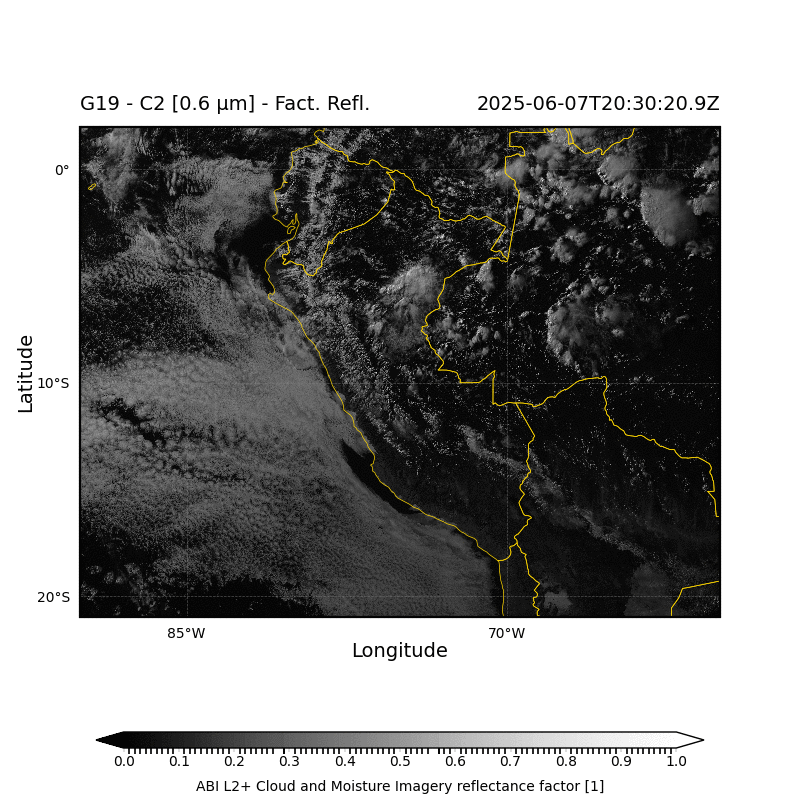

# Grafiquemos productos "baseline" del ABI a bordo del GOES-19

La descripción de los productos del GOES se encuentra en el siguiente link: https://github.com/NOAA-Big-Data-Program/nodd-data-docs/tree/main/GOES

# Total Precipitable Water

Descarguemos el archivo del producto Total Precipitable Water de full disk (ABI-L2-TPWF):

In [76]:
import GOES

flist = GOES.download('goes19',
                      'ABI-L2-TPWF',
                      DateTimeIni='20250607-233000',
                      DateTimeFin='20250608-000000',
                      path_out='/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/')

Files:
  OR_ABI-L2-TPWF-M6_G19_s20251582330209_e20251582339518_c20251582341310.nc already exists.
  OR_ABI-L2-TPWF-M6_G19_s20251582340209_e20251582349518_c20251582351220.nc already exists.
  OR_ABI-L2-TPWF-M6_G19_s20251582350209_e20251582359518_c20251590001345.nc already exists.


Definamos la paleta de colores para el producto TPW.

In [77]:
# Creación de una paleta de colores personalizada

import custom_color_palette as ccp

# Definimos los colores y el intervalo que ocupa en la paleta
paleta_1 = [['saddlebrown','sandybrown'], [0,1,2,3,4,5,6]]
paleta_2 = [['darkblue','cornflowerblue'], [6,7,8,9,10,11,12]]
paleta_3 = [['darkviolet','thistle'], [12,13,14,15,16,17,18]]
paleta_4 = [['darkcyan','cyan'], [18,19,20,21,22,23,24,25,26]]
paleta_5 = [['green','lime'], [26,27,28,29,30,31,32,33,34,35,36,37,38]]
paleta_6 = [['darkgoldenrod','yellow'], [38,39,40,41,42,43,44,45,46,47,48,49,50]]
paleta_7 = [['maroon','red'], [50,51,52,53,54,55]]
paleta_8 = [['purple','fuchsia'], [55,56,57,58,59,60]]
paleta_9 = [['lightgray','black'], [60,61,62,63,64,65,66,67,68,69,70]]

# Creamos la paleta personalizada
cmap, ticks, norm, bounds = ccp.creates_palette([paleta_1, paleta_2, paleta_3,
                                                 paleta_4, paleta_5, paleta_6,
                                                 paleta_7, paleta_8, paleta_9], extend='max')
cbticks = [0,6,12,18,26,38,50,55,60,70]

In [78]:
# Obteniendo el dato (imagen del producto)

import GOES

ds = GOES.open_dataset(flist[0]) # Leemos el archivo nc

print(ds)

<class 'GOES.processing.processing_data.open_dataset'>

attribute:
   naming_authority              : gov.nesdis.noaa
   Conventions                   : CF-1.7
   Metadata_Conventions          : Unidata Dataset Discovery v1.0
   standard_name_vocabulary      : CF Standard Name Table (v35, 20 July 2016)
   institution                   : DOC/NOAA/NESDIS > U.S. Department of Commerce, N...
   project                       : GOES
   production_site               : NSOF
   production_environment        : OE
   spatial_resolution            : 10.0km at nadir
   orbital_slot                  : GOES-East
   platform_ID                   : G19
   instrument_type               : GOES-R Series Advanced Baseline Imager (ABI)
   scene_id                      : Full Disk
   instrument_ID                 : FM4
   dataset_name                  : OR_ABI-L2-TPWF-M6_G19_s20251582330209_e202515823...
   iso_series_metadata_id        : 42511480-afef-11e1-afa6-0800200c9a66
   title                         

In [79]:
# Obtenemos el dato (imagen de satélite) y sus coordenadas (de las esquinas de cada elemento)
domain = [-88.0,-62.0,-21.0,2.0] # Definimos el dominio de longitud y latitud
TPW, LonCor, LatCor = ds.image('TPW', lonlat='corner', domain=domain)

# Atributos del dato (imagen de satélite)
sat = ds.attribute('platform_ID')
time = ds.attribute('time_coverage_start')
long_name = TPW.long_name # Lo obtenemos de TPW
units = TPW.units # Lo obtenemos de TPW

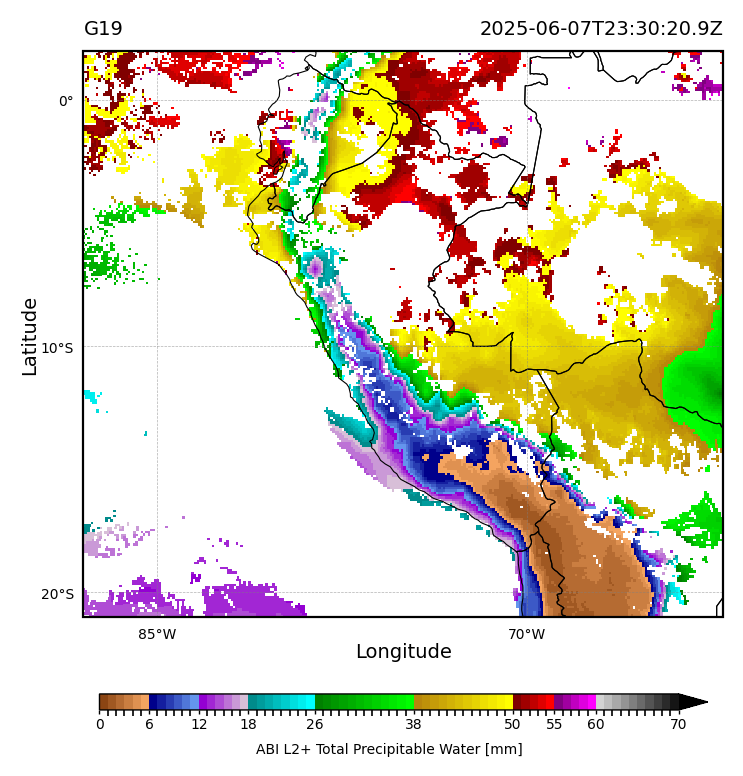

In [80]:
# Graficando el dato (imagen del producto)

import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt

proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='50m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='black', linewidth=0.40) # Adicionamos los limites

img = ax.pcolormesh(LonCor.data, LatCor.data, TPW.data, transform=proj_sat, cmap=cmap, norm=norm)

# Configuración de la barra de colores
cb = plt.colorbar(img, ticks=cbticks, orientation='horizontal', extend='max', cax=fig.add_axes([0.12, 0.065, 0.76, 0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)
cb.set_label(label='{} [{}]'.format(long_name, units), size=5, color='black', weight='normal')
cb.outline.set_linewidth(0.5)

# Configuración del titulo
ax.set_title('{}'.format(sat), fontsize=7, loc='left')
ax.set_title(time, fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_C08.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


<br>

# Rainfall Rate (Quantitative Precipitation Estimate) (ABI-L2-RRQPEF)

Descarguemos el archivo del producto RRQPE (Rainfall Rate - Quantitative Precipitation Estimate) de full disk (ABI-L2-RRQPEF):

In [82]:
import GOES

flist = GOES.download('goes19',
                      'ABI-L2-RRQPEF',
                      DateTimeIni='20250607-233000',
                      DateTimeFin='20250608-000000',
                      path_out='/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/')

Files:
  OR_ABI-L2-RRQPEF-M6_G19_s20251582330209_e20251582339518_c20251582340005.nc already exists.
  OR_ABI-L2-RRQPEF-M6_G19_s20251582340209_e20251582349518_c20251582349597.nc already exists.
  OR_ABI-L2-RRQPEF-M6_G19_s20251582350209_e20251582359518_c20251590000007.nc already exists.


Definamos la paleta de colores para el producto RRQPE

In [83]:
# Creación de una paleta de colores personalizada

import custom_color_palette as ccp

# Definimos los colores y el intervalo que ocupa en la paleta
paleta_1 = [['white','blueviolet'], [0,1,2,3,4,5]]
paleta_2 = [['blue','dodgerblue','lightskyblue'], [5,10,15,20,25,30]]
paleta_3 = [['green','limegreen','lime'], [30,35,40,45,50]]
paleta_4 = [['gold','orange','red','firebrick'], [50,55,60,65,70,75,80,85,90,95,100]]

# Creamos la paleta personalizada
cmap, ticks, norm, bounds = ccp.creates_palette([paleta_1, paleta_2, paleta_3, paleta_4], extend='max')
cbticks = ticks

In [84]:
# Obteniendo el dato (imagen del producto)

import GOES

ds = GOES.open_dataset(flist[0]) # Leemos el archivo nc

print(ds)

<class 'GOES.processing.processing_data.open_dataset'>

attribute:
   naming_authority              : gov.nesdis.noaa
   Conventions                   : CF-1.7
   Metadata_Conventions          : Unidata Dataset Discovery v1.0
   standard_name_vocabulary      : CF Standard Name Table (v35, 20 July 2016)
   institution                   : DOC/NOAA/NESDIS > U.S. Department of Commerce, N...
   project                       : GOES
   production_site               : NSOF
   production_environment        : OE
   spatial_resolution            : 2.0km at nadir
   orbital_slot                  : GOES-East
   platform_ID                   : G19
   instrument_type               : GOES-R Series Advanced Baseline Imager (ABI)
   scene_id                      : Full Disk
   instrument_ID                 : FM4
   dataset_name                  : OR_ABI-L2-RRQPEF-M6_G19_s20251582330209_e2025158...
   iso_series_metadata_id        : 3a3268a0-b006-11e1-afa6-0800200c9a66
   title                         :

In [85]:
# Obtenemos el dato (imagen de satélite) y sus coordenadas (de las esquinas de cada elemento)
domain = [-88.0,-62.0,-21.0,2.0] # Definimos el dominio de longitud y latitud
RRQPE, LonCor, LatCor = ds.image('RRQPE', lonlat='corner', domain=domain)

# Atributos del dato (imagen de satélite)
sat = ds.attribute('platform_ID')
time = ds.attribute('time_coverage_start')
long_name = RRQPE.long_name # Lo obtenemos de RRQPE
units = RRQPE.units # Lo obtenemos de RRQPE

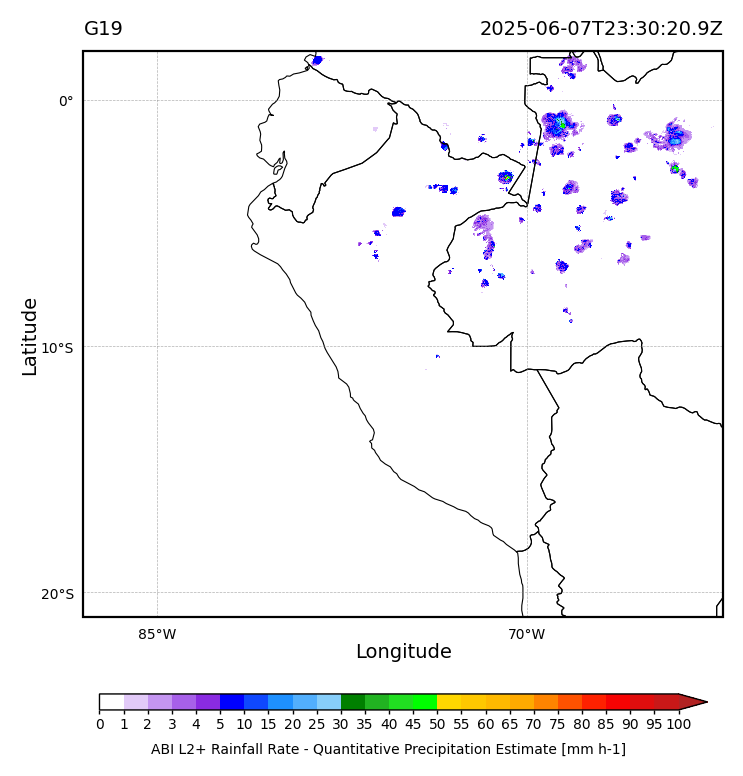

In [86]:
# Graficando el dato (imagen del producto)

import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt

proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='50m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='black', linewidth=0.40) # Adicionamos los limites

img = ax.pcolormesh(LonCor.data, LatCor.data, RRQPE.data, transform=proj_sat, cmap=cmap, norm=norm)

# Configuración de la barra de colores
cb = plt.colorbar(img, ticks=cbticks, orientation='horizontal', extend='max', cax=fig.add_axes([0.12, 0.065, 0.76, 0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)
cb.set_label(label='{} [{}]'.format(long_name, units), size=5, color='black', weight='normal')
cb.outline.set_linewidth(0.5)

# Configuración del titulo
ax.set_title('{}'.format(sat), fontsize=7, loc='left')
ax.set_title(time, fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_C08.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


In [87]:
import GOES

flist = GOES.download('goes19',
                      'ABI-L2-CMIPF',
                      DateTimeIni='20250613-053000',
                      DateTimeFin='20250613-053100',
                      channel=['07','08','10','12','13'],
                      path_out='/content/drive/MyDrive/Curso_GOES19_SENAMHI/GOES19/ABI/')

Files:
  OR_ABI-L2-CMIPF-M6C07_G19_s20251640530217_e20251640539537_c20251640539583.nc already exists.
  OR_ABI-L2-CMIPF-M6C08_G19_s20251640530217_e20251640539525_c20251640539586.nc already exists.
  OR_ABI-L2-CMIPF-M6C10_G19_s20251640530217_e20251640539537_c20251640539577.nc already exists.
  OR_ABI-L2-CMIPF-M6C12_G19_s20251640530217_e20251640539531_c20251640539588.nc already exists.
  OR_ABI-L2-CMIPF-M6C13_G19_s20251640530217_e20251640539536_c20251640539580.nc already exists.


Guardemos el nombre de cada archivo en una variable:

In [88]:
file_c07 = flist[0]
file_c08 = flist[1]
file_c10 = flist[2]
file_c12 = flist[3]
file_c13 = flist[4]

<br>

# Diferencias de canales

### 6.2 µm - 10.3 µm [IR - WV]

In [89]:
# Creación de una paleta de colores personalizada

import custom_color_palette as ccp
import matplotlib.pyplot as plt

# Definimos los colores y el intervalo que ocupa en la paleta
paleta_1 = [plt.cm.Greys_r, # sequencia de colores o paleta de matplotlib
            ccp.range(-90.0,-3.0,1.0), # intervalo que abarcan los colores
            [ccp.range(-90.0,60.0,1.0),-90.0,-3.0] # parametro opcional que estira y recorta la paleta de colores
            ]

paleta_2 = [['yellow','orange','red','magenta'], # sequencia de colores o paleta de matplotlib
            ccp.range(-3.0,60.0,1.0) # intervalo que abarcan los colores
            ]

# Creamos la paleta personalizada
cmap, ticks, norm, bounds = ccp.creates_palette([paleta_1,  paleta_2], extend='both')
cbticks = ccp.range(-90,60,15)

In [92]:
# Obteniendo el dato (imagen de satélite)

import GOES
import numpy as np

ds_c13 = GOES.open_dataset(file_c13) # Leemos el archivo nc

# Obtenemos el dato (imagen de satélite) y sus coordenadas (de las esquinas de cada elemento)
domain = [-100.0,-20.0,-60.0,20.0] # Definimos el dominio de longitud y latitud
CMI_C13, LonCor, LatCor = ds_c13.image('CMI', lonlat='corner', domain=domain)

# Atributos del dato (imagen de satélite)
sat = ds_c13.attribute('platform_ID')
time = ds_c13.attribute('time_coverage_start')
title = '6.19 μm - 10.3 μm'
long_name = 'Diferencia de Temperatura de brillo'
units = 'K'

domain_in_pixels = CMI_C13.pixels_limits
mask = np.where(np.isnan(CMI_C13.data)==True, True, False)

In [93]:
ds_c08 = GOES.open_dataset(file_c08) # Leemos el archivo nc
CMI_C08, _, _ = ds_c08.image('CMI', lonlat='none', domain_in_pixels=domain_in_pixels, nan_mask=mask)

In [94]:
DC08C13 = CMI_C08.data - CMI_C13.data

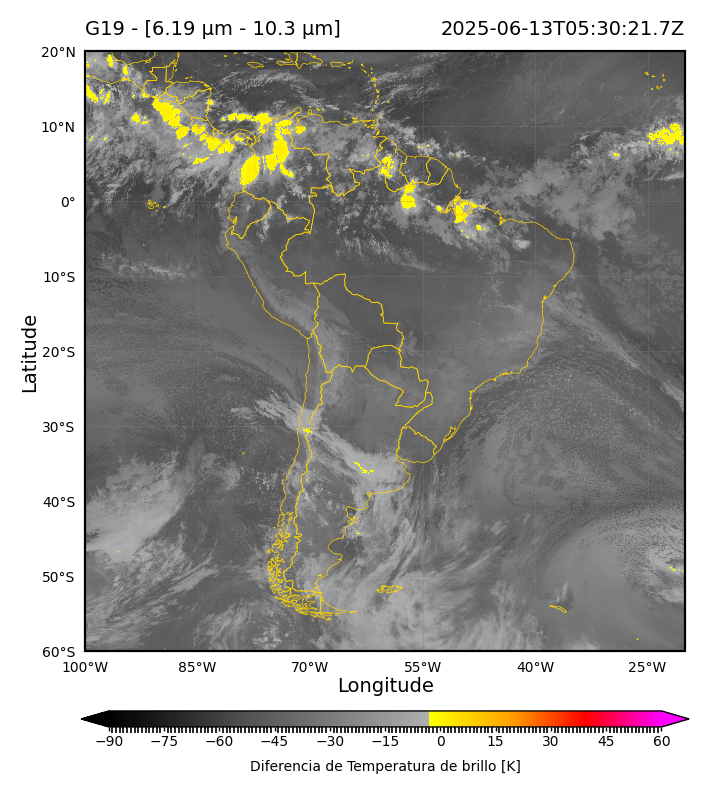

In [95]:
# Graficando el dato (imagen de satélite)

import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt

proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='50m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='gold', linewidth=0.25) # Adicionamos los limites

img = ax.pcolormesh(LonCor.data, LatCor.data, DC08C13, transform=proj_sat, cmap=cmap, norm=norm)

# Configuración de la barra de colores
cb = plt.colorbar(img, ticks=cbticks, orientation='horizontal', extend='both', cax=fig.add_axes([0.12, 0.065, 0.76, 0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)
cb.set_label(label='{} [{}]'.format(long_name, units), size=5, color='black', weight='normal')
cb.outline.set_linewidth(0.5)

# Configuración del titulo
ax.set_title('{} - [{}]'.format(sat, title), fontsize=7, loc='left')
ax.set_title(time, fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_DC08C13.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


¡Eliminemos las variables para evitar que se llene la memoria RAM del Colab!

In [96]:
del CMI_C13, CMI_C08, DC08C13, LonCor, LatCor, ds_c08, ds_c13, img, fig

<br>

### 3.9 µm - 10.3 µm

In [97]:
# Creación de una paleta de colores personalizada

import custom_color_palette as ccp
import matplotlib.pyplot as plt

# Definimos los colores y el intervalo que ocupa en la paleta
paleta_1 = [plt.cm.Greys, # sequencia de colores o paleta de matplotlib
            ccp.range(-40.0,2.0,1.0), # intervalo que abarcan los colores
            [ccp.range(-40.0,10.0,1.0),-40.0,2.0] # parametro opcional que estira y recorta la paleta de colores
            ]

paleta_2 = [['darkcyan','cyan'], # sequencia de colores o paleta de matplotlib
            ccp.range(2.0,5.0,1.0) # intervalo que abarcan los colores
            ]

paleta_3 = [['lightsteelblue','blue'], # sequencia de colores o paleta de matplotlib
            ccp.range(5.0,60.0,1.0) # intervalo que abarcan los colores
            ]

# Creamos la paleta personalizada
cmap, ticks, norm, bounds = ccp.creates_palette([paleta_1,  paleta_2,  paleta_3], extend='both')
cbticks = ccp.range(-90,60,15)

In [98]:
# Obteniendo el dato (imagen de satélite)

import GOES
import numpy as np

ds_c13 = GOES.open_dataset(file_c13) # Leemos el archivo nc

# Obtenemos el dato (imagen de satélite) y sus coordenadas (de las esquinas de cada elemento)
domain = [-90.0,-60.0,-21.0,2.0] # Definimos el dominio de longitud y latitud
CMI_C13, LonCor, LatCor = ds_c13.image('CMI', lonlat='corner', domain=domain)

# Atributos del dato (imagen de satélite)
sat = ds_c13.attribute('platform_ID')
time = ds_c13.attribute('time_coverage_start')
title = '10.3 μm - 3.9 μm'
long_name = 'Diferencia de Temperatura de brillo'
units = 'K'

domain_in_pixels = CMI_C13.pixels_limits
mask = np.where(np.isnan(CMI_C13.data)==True, True, False)

In [99]:
ds_c07 = GOES.open_dataset(file_c07) # Leemos el archivo nc
CMI_C07, _, _ = ds_c07.image('CMI', lonlat='none', domain_in_pixels=domain_in_pixels, nan_mask=mask)

In [100]:
DC13C07 = CMI_C13.data - CMI_C07.data

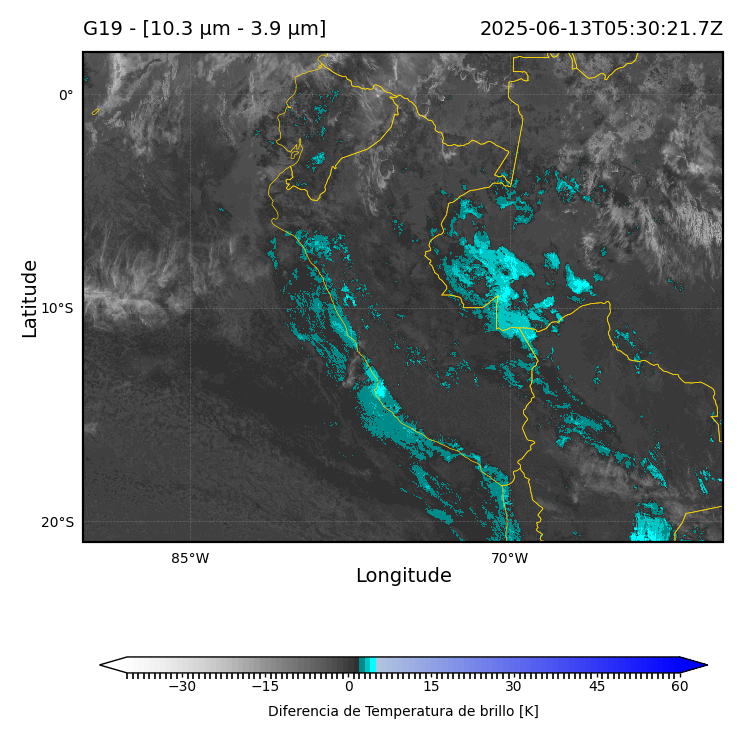

In [101]:
# Graficando el dato (imagen de satélite)

import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt

proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='50m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='gold', linewidth=0.25) # Adicionamos los limites

img = ax.pcolormesh(LonCor.data, LatCor.data, DC13C07, transform=proj_sat, cmap=cmap, norm=norm)

# Configuración de la barra de colores
cb = plt.colorbar(img, ticks=cbticks, orientation='horizontal', extend='both', cax=fig.add_axes([0.12, 0.065, 0.76, 0.02]))
cb.ax.tick_params(labelsize=5, labelcolor='black', width=0.5, length=1.5, direction='out', pad=1.0)
cb.set_label(label='{} [{}]'.format(long_name, units), size=5, color='black', weight='normal')
cb.outline.set_linewidth(0.5)

# Configuración del titulo
ax.set_title('{} - [{}]'.format(sat, title), fontsize=7, loc='left')
ax.set_title(time, fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_DC07C13.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


<br>

# Combinaciónes RGB

# Grafiquemos el RGB - Masa de Aire (sin re-grillado):

In [102]:
import GOES

C08_ds = GOES.open_dataset(file_c08)
C10_ds = GOES.open_dataset(file_c10)
C12_ds = GOES.open_dataset(file_c12)
C13_ds = GOES.open_dataset(file_c13)

In [109]:
domain = [-90.0,-30.0,-60.0,15.0]
C08, LonCor, LatCor = C08_ds.image('CMI', lonlat='corner', domain=domain)

sat = C08_ds.attribute('platform_ID')
time = C08_ds.variable('time_bounds').data[0]
domain_in_pixels = C08.pixels_limits
title = 'Masa de Aire'

In [104]:
print(domain_in_pixels)

[1894 4840 1899 5215]


In [106]:
import numpy as np
mask = np.where(np.isnan(C08.data)==True, True, False)

In [112]:
C10, _, _ = C10_ds.image('CMI', lonlat='none', domain_in_pixels=domain_in_pixels, nan_mask=mask)
C12, _, _ = C12_ds.image('CMI', lonlat='none', domain_in_pixels=domain_in_pixels, nan_mask=mask)
C13, _, _ = C13_ds.image('CMI', lonlat='none', domain_in_pixels=domain_in_pixels, nan_mask=mask)

In [113]:
import numpy as np

# Definimos los canales R, G y B
R = C08.data - C10.data
G = C12.data - C13.data
B = C08.data - 273.15

# Limitamos los valores de los canales
Rmin, Rmax = -26.2, 0.6
Gmin, Gmax = -43.2, 6.7
Bmin, Bmax = -64.65, -29.25
R = np.clip(R, Rmin, Rmax)
G = np.clip(G, Gmin, Gmax)
B = np.clip(B, Bmin, Bmax)

# Normalizamos los canales (los transforma a valores entre 0 y 1)
R = (R-Rmin)/(Rmax-Rmin)
G = (G-Gmin)/(Gmax-Gmin)
B = (B-Bmin)/(Bmax-Bmin)

# Realizamos la corrección gamma
R_gamma, G_gamma, B_gamma = 1, 1, 1
R = np.power(R, 1/R_gamma)
G = np.power(G, 1/G_gamma)
B = np.power(B, 1/B_gamma)

# Invertimos el channel
B = 1.0 - B

In [114]:
# Apilamos los canales
RGB = np.dstack((R, G, B)).astype(np.float16)

# Cambiamos la forma de RGB (de 2D a 1D)
RGB = RGB.reshape((RGB.shape[0]*RGB.shape[1],RGB.shape[2]))

# Nos aseguramos que RGB este entre 0 y 1
RGB = np.clip(RGB, 0.0, 1.0, dtype=RGB.dtype)

# Creamos un simple array para hacer un grafico con pcolormesh
mask = np.where(mask==True,np.nan, 1).astype(np.float16)

In [116]:
print(mask)

[[ 1.  1.  1. ...  1.  1.  1.]
 [ 1.  1.  1. ...  1.  1.  1.]
 [ 1.  1.  1. ...  1.  1.  1.]
 ...
 [ 1.  1.  1. ... nan nan nan]
 [ 1.  1.  1. ... nan nan nan]
 [ 1.  1.  1. ... nan nan nan]]


In [117]:
print(RGB)

[[0.332  0.5337 0.3154]
 [0.347  0.533  0.3154]
 [0.427  0.5586 0.3237]
 ...
 [   nan    nan    nan]
 [   nan    nan    nan]
 [   nan    nan    nan]]


In [115]:
# Eliminamos algunas variables
del C08, C10, C12, C13, R, G, B

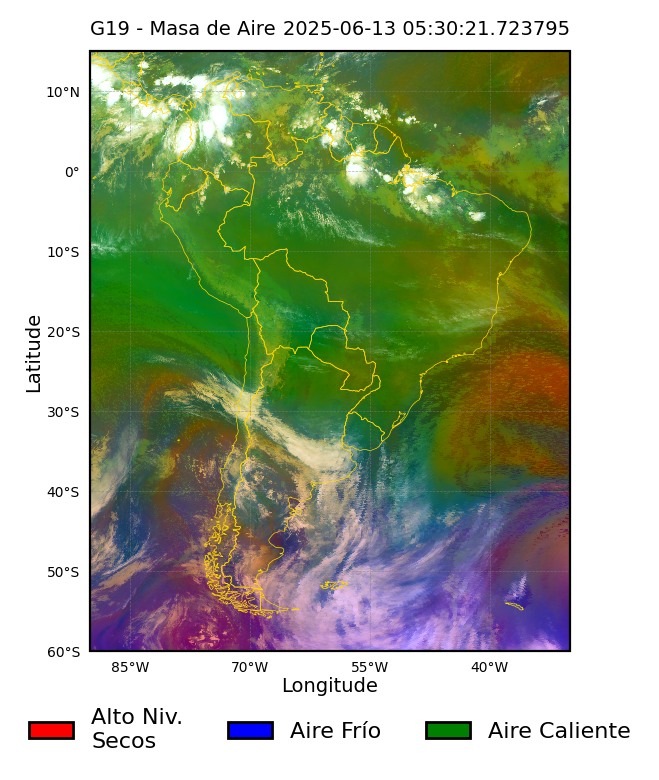

In [118]:
# Graficando el dato (imagen de satélite)

import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='50m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='gold', linewidth=0.25) # Adicionamos los limites

img = ax.pcolormesh(LonCor.data, LatCor.data, mask, transform=proj_sat, color=RGB)


# Crear recuadros personalizados
legend_elements = [
    Patch(facecolor='red', edgecolor='black', label='Alto Niv.\nSecos'),
    Patch(facecolor='blue', edgecolor='black', label='Aire Frío'),
    Patch(facecolor='green', edgecolor='black', label='Aire Caliente'),
]

ax.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.2),  # ajusta el segundo valor para separar más o menos de la figura
    ncol=3,  # número de columnas
    frameon=False,  # opcional: sin borde
    fontsize=8
)

# Configuración del titulo
ax.set_title('{} - {}'.format(sat, title), fontsize=7, loc='left')
ax.set_title(time, fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_RGB_AirMass.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura


¡Eliminemos las variables para evitar que se llene la memoria RAM del Colab!

In [119]:
del RGB, mask, LonCor, LatCor, img, fig

<br>

# Grafiquemos el RGB - Masa de Aire (con re-grillado):

In [54]:
import GOES

C08_ds = GOES.open_dataset(file_c08)
C10_ds = GOES.open_dataset(file_c10)
C12_ds = GOES.open_dataset(file_c12)
C13_ds = GOES.open_dataset(file_c13)

In [55]:
domain = [-90.0,-30.0,-60.0,15.0] # Definimos el dominio de longitud y latitud

In [56]:
# Creamos una grilla regular de 2 km.
LonCenCyl, LatCenCyl = GOES.create_gridmap(domain, PixResol=2.0)

In [57]:
# Calculamos las coordenadas de las esquinas de la grilla regular de 1 km.
LonCorCyl, LatCorCyl = GOES.calculate_corners(LonCenCyl, LatCenCyl)

In [58]:
# Definimos parametros para la reproyección.
import pyproj as pyproj
Prj = pyproj.Proj('+proj=eqc +lat_ts=0 +lat_0=0 +lon_0=0 +x_0=0 +y_0=0 +a=6378.137 +b=6378.137 +units=km')
AreaID = 'cyl'
AreaName = 'cyl'
ProjID = 'cyl'
Proj4Args = '+proj=eqc +lat_ts=0 +lat_0=0 +lon_0=0 +x_0=0 +y_0=0 +a=6378.137 +b=6378.137 +units=km'

ny, nx = LonCenCyl.data.shape
SW = Prj(LonCenCyl.data.min(), LatCenCyl.data.min())
NE = Prj(LonCenCyl.data.max(), LatCenCyl.data.max())
area_extent = [SW[0], SW[1], NE[0], NE[1]]

from pyresample import utils
AreaDef = utils.get_area_def(AreaID, AreaName, ProjID, Proj4Args, nx, ny, area_extent)

<br>

In [59]:
# Obtenemos la imagen de C03 y las coordenadas centrales de sus pixeles.
C08, C08_LonCen, C08_LatCen = C08_ds.image('CMI', lonlat='center', domain=domain)

sat = C08_ds.attribute('platform_ID')
time = C08_ds.variable('time_bounds').data[0]
title = 'Masa de Aire'

In [60]:
import numpy as np
from pyresample.geometry import SwathDefinition
from pyresample.kd_tree import resample_nearest

In [61]:
# Reproyectamos la imagen de C08 a la grilla regular de 2 km.
SwathDef = SwathDefinition(lons=C08_LonCen.data, lats=C08_LatCen.data)
C08Cyl = resample_nearest(SwathDef, C08.data, AreaDef, radius_of_influence=6000,
                          fill_value=np.nan, epsilon=3, reduce_data=True)

In [62]:
# Eliminamos algunas variables para evitar que se llene la memoria RAM del Colab
del C08, C08_LonCen, C08_LatCen

<br>

In [63]:
# Obtenemos la imagen de C10 y las coordenadas centrales de sus pixeles.
C10, C10_LonCen, C10_LatCen = C10_ds.image('CMI', lonlat='center', domain=domain)

In [64]:
# Reproyectamos la imagen de C10 a la grilla regular de 2 km.
SwathDef = SwathDefinition(lons=C10_LonCen.data, lats=C10_LatCen.data)
C10Cyl = resample_nearest(SwathDef, C10.data, AreaDef, radius_of_influence=6000,
                          fill_value=np.nan, epsilon=3, reduce_data=True)

In [65]:
# Eliminamos algunas variables para evitar que se llene la memoria RAM del Colab
del C10, C10_LonCen, C10_LatCen

<br>

In [66]:
# Obtenemos la imagen de C12 y las coordenadas centrales de sus pixeles.
C12, C12_LonCen, C12_LatCen = C12_ds.image('CMI', lonlat='center', domain=domain)

In [67]:
# Reproyectamos la imagen de C12 a la grilla regular de 2 km.
SwathDef = SwathDefinition(lons=C12_LonCen.data, lats=C12_LatCen.data)
C12Cyl = resample_nearest(SwathDef, C12.data, AreaDef, radius_of_influence=6000,
                          fill_value=np.nan, epsilon=3, reduce_data=True)

In [68]:
# Eliminamos algunas variables para evitar que se llene la memoria RAM del Colab
del C12, C12_LonCen, C12_LatCen

<br>

In [69]:
# Obtenemos la imagen de C13 y las coordenadas centrales de sus pixeles.
C13, C13_LonCen, C13_LatCen = C13_ds.image('CMI', lonlat='center', domain=domain)

In [70]:
# Reproyectamos la imagen de C13 a la grilla regular de 2 km.
SwathDef = SwathDefinition(lons=C13_LonCen.data, lats=C13_LatCen.data)
C13Cyl = resample_nearest(SwathDef, C13.data, AreaDef, radius_of_influence=6000,
                          fill_value=np.nan, epsilon=3, reduce_data=True)

In [71]:
# Eliminamos algunas variables para evitar que se llene la memoria RAM del Colab
del C13, C13_LonCen, C13_LatCen

<br>

In [72]:
# Definimos los canales R, G y B
R = C08Cyl - C10Cyl
G = C12Cyl - C13Cyl
B = C08Cyl - 273.15

# Limitamos los valores de los canales
Rmin, Rmax = -26.2, 0.6
Gmin, Gmax = -43.2, 6.7
Bmin, Bmax = -64.65, -29.25
R = np.clip(R, Rmin, Rmax)
G = np.clip(G, Gmin, Gmax)
B = np.clip(B, Bmin, Bmax)

# Normalizamos los canales (los transforma a valores entre 0 y 1)
R = (R-Rmin)/(Rmax-Rmin)
G = (G-Gmin)/(Gmax-Gmin)
B = (B-Bmin)/(Bmax-Bmin)

# Realizamos la corrección gamma
R_gamma, G_gamma, B_gamma = 1, 1, 1
R = np.power(R, 1/R_gamma)
G = np.power(G, 1/G_gamma)
B = np.power(B, 1/B_gamma)

# Invertimos el channel
B = 1.0 - B

In [73]:
# Apilamos los canales
RGB = np.dstack((R, G, B)).astype(np.float16)

# Cambiamos la forma de RGB (de 2D a 1D)
RGB = RGB.reshape((RGB.shape[0]*RGB.shape[1],RGB.shape[2]))

# Nos aseguramos que RGB este entre 0 y 1
RGB = np.clip(RGB, 0.0, 1.0, dtype=RGB.dtype)

# Creamos un simple array para hacer un grafico con pcolormesh
mask = np.where(np.isnan(C13Cyl)==True, np.nan, 1).astype(np.float16)

In [74]:
# Eliminamos algunas variables
del C08Cyl, C10Cyl, C12Cyl, C13Cyl, R, G, B

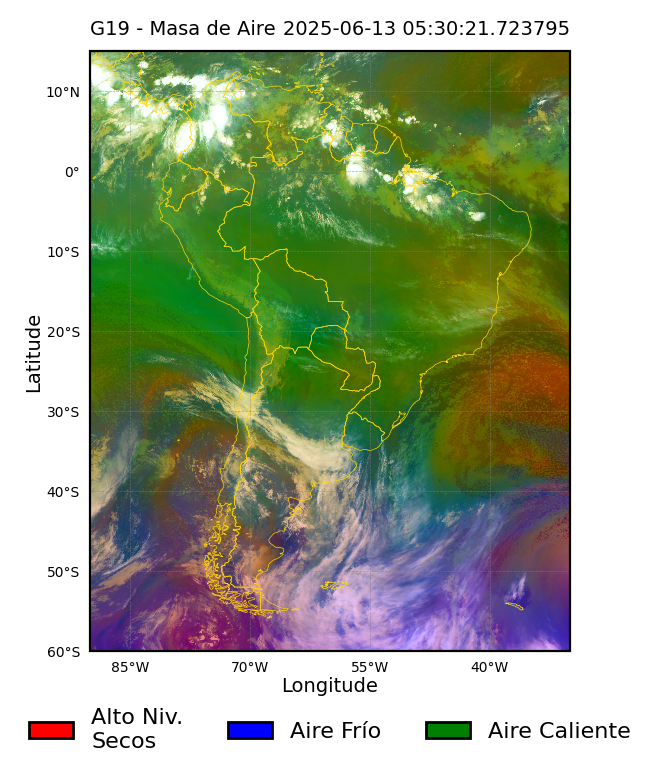

In [75]:
# Graficando el dato (imagen de satélite)

import numpy as np
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

proj_fig = ccrs.PlateCarree() # Proyección de la figura
proj_sat = ccrs.PlateCarree() # Proyección del dato

fig = plt.figure('map', figsize=(4,4), dpi=200) # Definimos las características de la figura
ax = fig.add_axes([0.1, 0.16, 0.80, 0.75], projection=proj_fig) # Definimos dónde se graficará el dato

l = NaturalEarthFeature(category='cultural', name='admin_0_countries', scale='50m', facecolor='none') # Definimos los limites
ax.add_feature(l, edgecolor='gold', linewidth=0.25) # Adicionamos los limites

img = ax.pcolormesh(LonCorCyl.data, LatCorCyl.data, mask, transform=proj_sat, color=RGB)


# Crear recuadros personalizados
legend_elements = [
    Patch(facecolor='red', edgecolor='black', label='Alto Niv.\nSecos'),
    Patch(facecolor='blue', edgecolor='black', label='Aire Frío'),
    Patch(facecolor='green', edgecolor='black', label='Aire Caliente'),
]

ax.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.2),  # ajusta el segundo valor para separar más o menos de la figura
    ncol=3,  # número de columnas
    frameon=False,  # opcional: sin borde
    fontsize=8
)

# Configuración del titulo
ax.set_title('{} - {}'.format(sat, title), fontsize=7, loc='left')
ax.set_title(time, fontsize=7, loc='right')

# Configuración de los ejes
xticks = np.arange(-160, 30, 15)
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(dateline_direction_label=True))
ax.set_xlabel('Longitude', color='black', fontsize=7, labelpad=0.5)

yticks = np.arange(90, -100, -10)
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_ylabel('Latitude', color='black', fontsize=7, labelpad=0.5)

ax.tick_params(left=True, right=True, bottom=True, top=True,
               labelleft=True, labelright=False, labelbottom=True, labeltop=False,
               length=0.0, width=0.05, labelsize=5.0, labelcolor='black')

# Configuración de las líneas de longitud y latitud
ax.gridlines(xlocs=xticks, ylocs=yticks, alpha=0.6, color='gray',
             draw_labels=False, linewidth=0.25, linestyle='--')

# Definimos los límites de longitud y latitud
ax.set_xlim(domain[0], domain[1])
ax.set_ylim(domain[2], domain[3])

plt.savefig('exemplo_plot_RGB_AirMass.png') # Guardamos la figura
plt.show() # Mostramos la figura
plt.close() # Cerramos la figura
